In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("hyd_v2.csv")

In [3]:
df.head()

,active,amenities,balconies,bathroom,combineDescription,completeStreetName,deposit,facing,facingDesc,floor,...,property_size,reactivationSource,rent_amount,sharedAccomodation,shortUrl,swimmingPool,totalFloor,type_bhk,waterSupply,weight
0,True,"{""LIFT"":true,""GYM"":false,""INTERNET"":false,""AC""...",3.0,3,NaN,"Shreya carnation, Block I, NCB Enclave, Gachib...",90000,W,West,3,...,2200,USER_DASHBOARD,28000,False,http://nobr.kr/sv/9Kvqj,False,5,BHK3,CORP_BORE,NaN
1,True,"{""LIFT"":false,""GYM"":false,""INTERNET"":false,""AC...",1.0,2,NaN,"Inner Ring Rd, near RTO Bandlaguda South Zone",45000,E,East,2,...,1200,USER_DASHBOARD,15000,False,http://nobr.kr/sv/j2pD6,False,2,BHK3,BOREWELL,NaN
2,True,"{""LIFT"":true,""GYM"":true,""INTERNET"":false,""AC"":...",3.0,3,NaN,"Rd Number 2, Shirdi Sai Nagar, Manikonda, Hyde...",80000,E,East,0,...,1800,MISSED_CALL,16000,False,http://nobr.kr/sv/TXJmj,False,3,BHK3,CORP_BORE,NaN
3,True,"{""LIFT"":false,""GYM"":false,""INTERNET"":false,""AC...",1.0,2,NaN,"Plot No. 44, Road No. 1/A, kakatiya colony, LB...",18000,W,West,2,...,750,MISSED_CALL,9000,False,http://nobr.kr/sv/FnCsf,False,2,BHK2,CORP_BORE,NaN
4,True,"{""LIFT"":true,""GYM"":false,""INTERNET"":false,""AC""...",2.0,2,NaN,"Madhapur HUDA Techno Enclave, Near MaxCure Su...",80000,E,East,2,...,1250,NaN,32500,False,http://nobr.kr/sv/BQFRb,False,5,BHK2,CORP_BORE,NaN


In [4]:
df.columns

Index(['active', 'amenities', 'balconies', 'bathroom', 'combineDescription',
       'completeStreetName', 'deposit', 'facing', 'facingDesc', 'floor',
       'furnishingDesc', 'gym', 'id', 'isMaintenance', 'lift', 'loanAvailable',
       'locality', 'localityId', 'location', 'maintenanceAmount', 'ownerName',
       'parking', 'parkingDesc', 'propertyTitle', 'propertyType',
       'property_age', 'property_size', 'reactivationSource', 'rent_amount',
       'sharedAccomodation', 'shortUrl', 'swimmingPool', 'totalFloor',
       'type_bhk', 'waterSupply', 'weight'],
      dtype='object')

In [5]:
df.dtypes

active                   bool
amenities              object
balconies             float64
bathroom                int64
combineDescription    float64
completeStreetName     object
deposit                 int64
facing                 object
facingDesc             object
floor                   int64
furnishingDesc         object
gym                      bool
id                     object
isMaintenance            bool
lift                     bool
loanAvailable            bool
locality               object
localityId             object
location               object
maintenanceAmount     float64
ownerName              object
parking                object
parkingDesc            object
propertyTitle          object
propertyType           object
property_age            int64
property_size           int64
reactivationSource     object
rent_amount             int64
sharedAccomodation       bool
shortUrl               object
swimmingPool             bool
totalFloor              int64
type_bhk  

In [11]:
data = df[['locality','bathroom','floor','furnishingDesc','isMaintenance','lift','parkingDesc','type_bhk','rent_amount']]
data.head()

,locality,bathroom,floor,furnishingDesc,isMaintenance,lift,parkingDesc,type_bhk,rent_amount
0,Gachibowli,3,3,Semi,True,True,Bike and Car,BHK3,28000
1,Chandrayangutta,2,2,Unfurnished,False,False,Bike,BHK3,15000
2,Manikonda,3,0,Semi,True,True,Bike and Car,BHK3,16000
3,LB Nagar,2,2,Unfurnished,True,False,Bike and Car,BHK2,9000
4,HITEC City,2,2,Semi,True,True,Bike and Car,BHK2,32500


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19110 entries, 0 to 19109
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   locality        19104 non-null  object
 1   bathroom        19110 non-null  int64 
 2   floor           19110 non-null  int64 
 3   furnishingDesc  19110 non-null  object
 4   isMaintenance   19110 non-null  bool  
 5   lift            19110 non-null  bool  
 6   parkingDesc     18160 non-null  object
 7   type_bhk        19110 non-null  object
 8   rent_amount     19110 non-null  int64 
dtypes: bool(2), int64(3), object(4)
memory usage: 1.1+ MB


In [16]:
data.isnull().sum()

locality            6
bathroom            0
floor               0
furnishingDesc      0
isMaintenance       0
lift                0
parkingDesc       950
type_bhk            0
rent_amount         0
dtype: int64

In [18]:
data1 = data.dropna()

In [20]:
data1.isnull().sum()

locality          0
bathroom          0
floor             0
furnishingDesc    0
isMaintenance     0
lift              0
parkingDesc       0
type_bhk          0
rent_amount       0
dtype: int64

In [22]:
data1.shape

(18154, 9)

In [24]:
data1['locality'].unique

<bound method Series.unique of 0             Gachibowli
1        Chandrayangutta
2              Manikonda
3               LB Nagar
4             HITEC City
              ...       
19105         Gachibowli
19106         Jillalguda
19107           Moosapet
19108         Kukatpally
19109      Santosh Nagar
Name: locality, Length: 18154, dtype: object>

In [26]:
data1.groupby("locality")['type_bhk'].value_counts().sort_values(ascending = False)

locality    type_bhk
Kukatpally  BHK2        801
Kondapur    BHK3        445
            BHK2        428
Miyapur     BHK2        343
Kukatpally  BHK1        303
                       ... 
Jilleguda   BHK2          1
Jillelguda  BHK1          1
            BHK2          1
Jodimetla   BHK1          1
zzathnagar  RK1           1
Name: count, Length: 3772, dtype: int64

In [28]:
data1.dtypes

locality          object
bathroom           int64
floor              int64
furnishingDesc    object
isMaintenance       bool
lift                bool
parkingDesc       object
type_bhk          object
rent_amount        int64
dtype: object

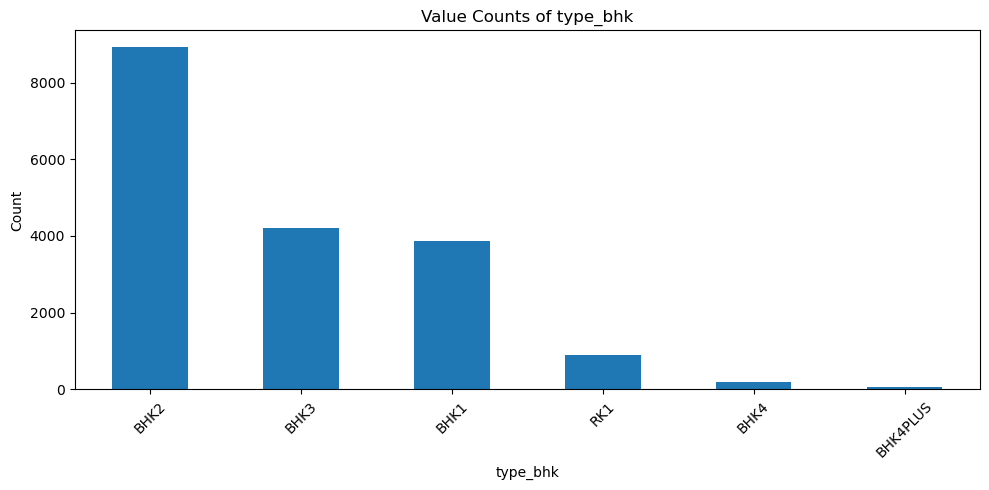

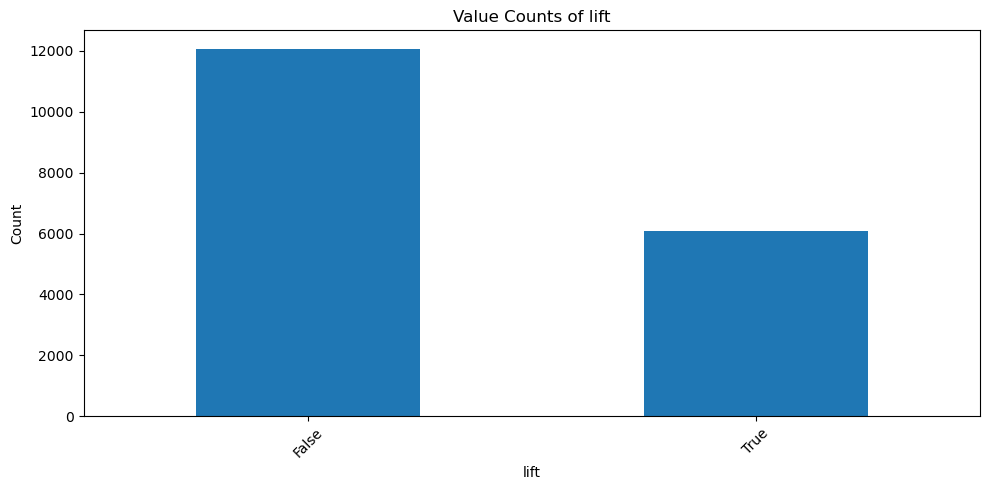

In [30]:
# matplotlib
columns_to_plot = ['type_bhk', 'lift']  # Add your columns here

for col in columns_to_plot:
    plt.figure(figsize=(10, 5))
    data1[col].value_counts().plot(kind='bar')
    plt.title(f'Value Counts of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

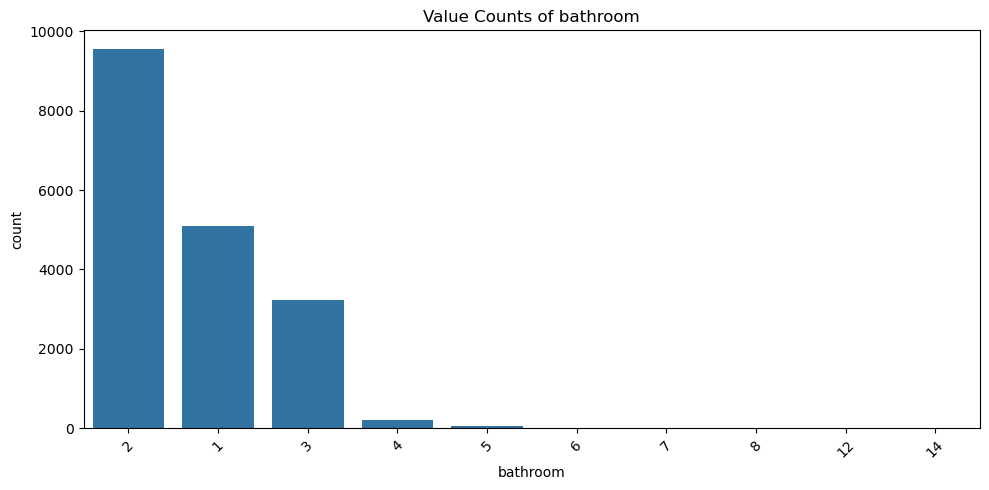

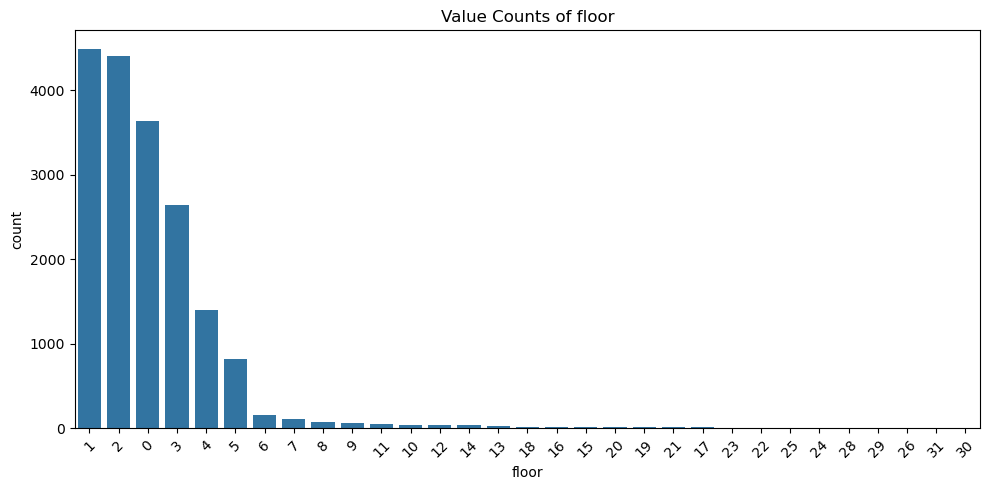

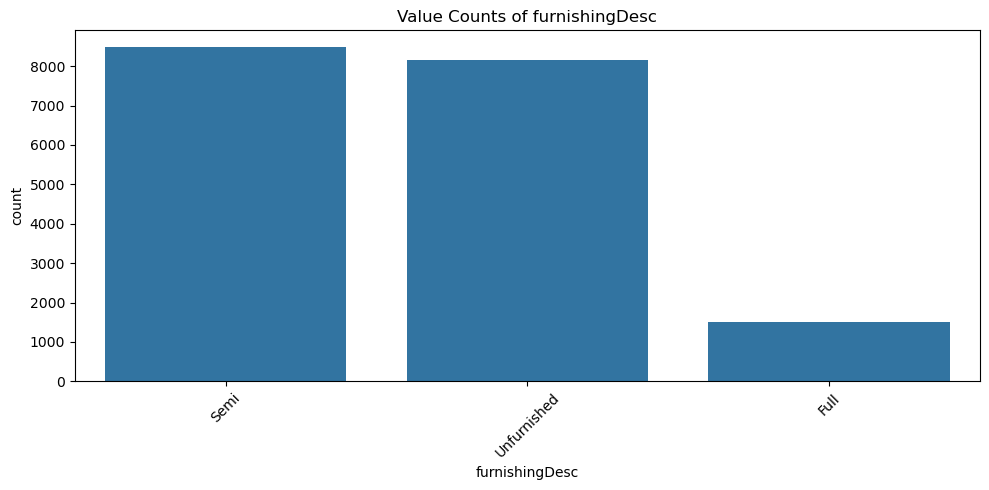

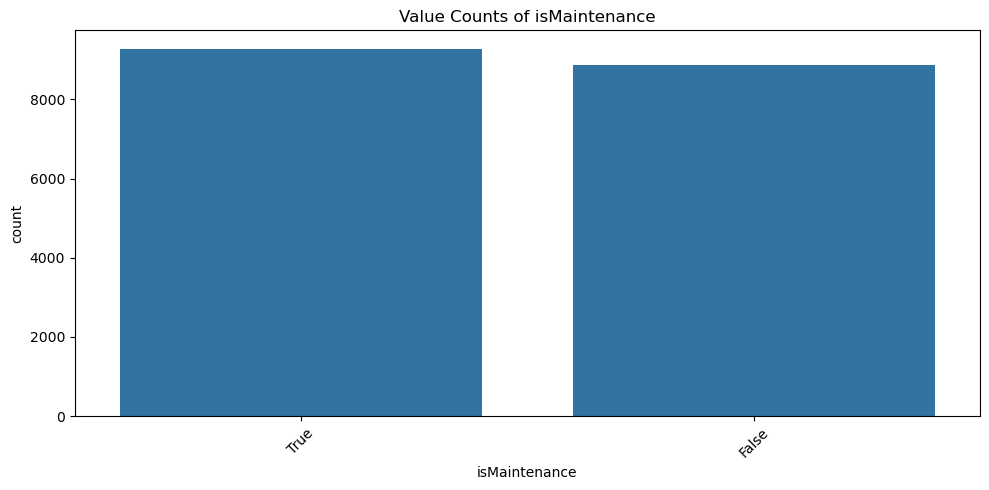

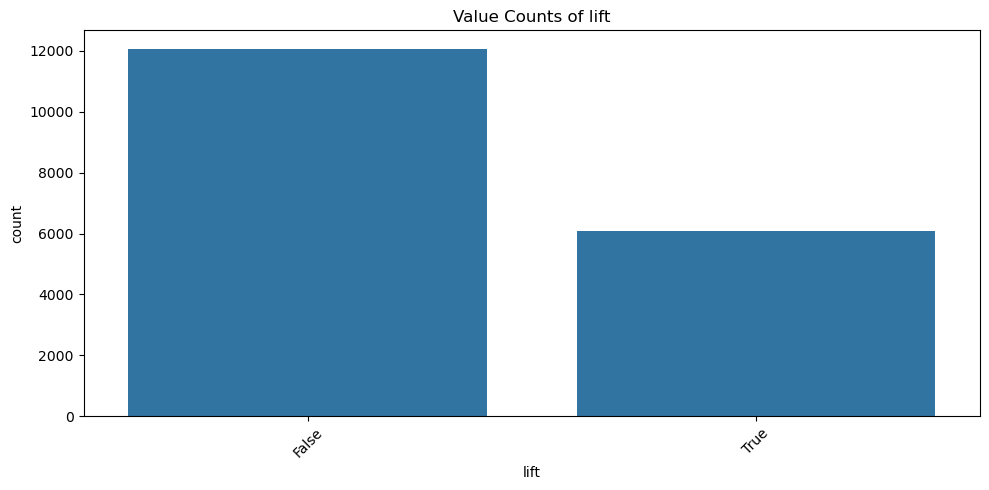

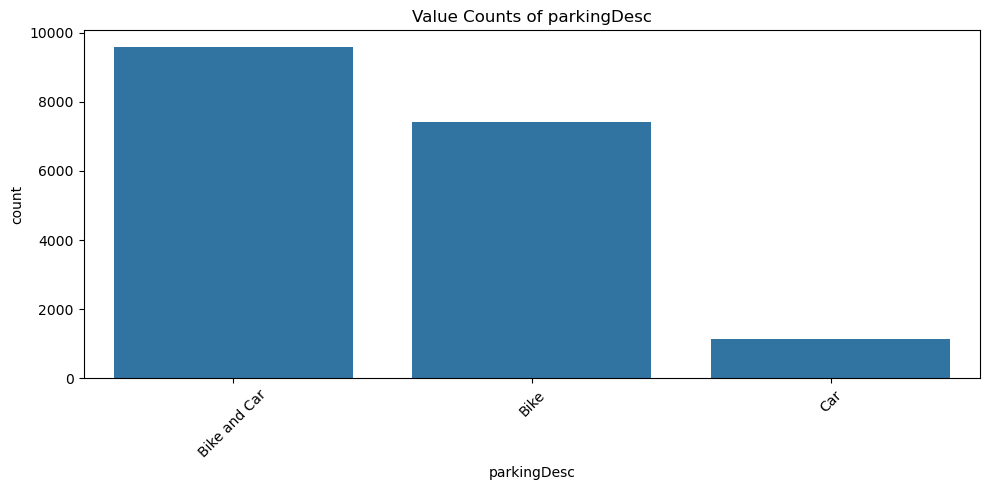

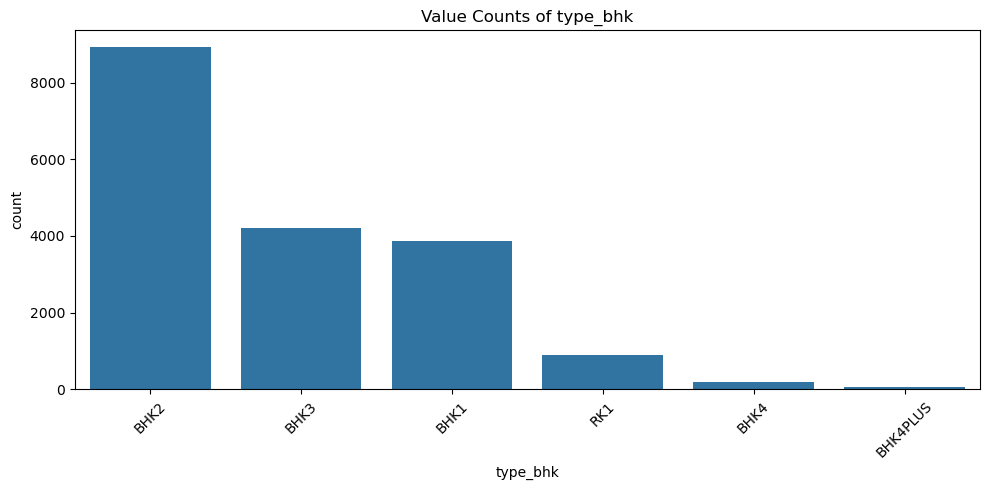

In [32]:
# seaborn
columns_to_plot = ['bathroom','floor','furnishingDesc','isMaintenance','lift','parkingDesc','type_bhk']
for col in columns_to_plot:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=data1, x=col, order=data1[col].value_counts().index)
    plt.title(f'Value Counts of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [33]:
data['furnishingDesc'].unique()

array(['Semi', 'Unfurnished', 'Full'], dtype=object)

In [34]:
data2 = data1.copy()

In [38]:
data2['bhk'] = data2['type_bhk'].apply(lambda x: int(''.join(filter(str.isdigit, str(x)))))

In [40]:
data2.head()

,locality,bathroom,floor,furnishingDesc,isMaintenance,lift,parkingDesc,type_bhk,rent_amount,bhk
0,Gachibowli,3,3,Semi,True,True,Bike and Car,BHK3,28000,3
1,Chandrayangutta,2,2,Unfurnished,False,False,Bike,BHK3,15000,3
2,Manikonda,3,0,Semi,True,True,Bike and Car,BHK3,16000,3
3,LB Nagar,2,2,Unfurnished,True,False,Bike and Car,BHK2,9000,2
4,HITEC City,2,2,Semi,True,True,Bike and Car,BHK2,32500,2


In [42]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
data2.loc[:, 'isMaintenance'] = data2['isMaintenance'].replace({'True': 1, 'False': 0})
data2.loc[:, 'lift'] = data2['lift'].replace({'True': 1, 'False': 0})
data2.loc[:, 'furnishingDesc'] = data2['furnishingDesc'].replace({'Full': 1, 'Semi': 2, 'Unfurnished': 3})
data2.loc[:, 'parkingDesc'] = data2['parkingDesc'].replace({'Bike': 1, 'Car': 2, 'Bike and Car': 3})



In [44]:
data2.head()

,locality,bathroom,floor,furnishingDesc,isMaintenance,lift,parkingDesc,type_bhk,rent_amount,bhk
0,Gachibowli,3,3,2,True,True,3,BHK3,28000,3
1,Chandrayangutta,2,2,3,False,False,1,BHK3,15000,3
2,Manikonda,3,0,2,True,True,3,BHK3,16000,3
3,LB Nagar,2,2,3,True,False,3,BHK2,9000,2
4,HITEC City,2,2,2,True,True,3,BHK2,32500,2


In [46]:
data3  = data2.drop(["type_bhk", 'furnishingDesc','isMaintenance','bathroom'], axis = 1) 

In [48]:
data3.head()

,locality,floor,lift,parkingDesc,rent_amount,bhk
0,Gachibowli,3,True,3,28000,3
1,Chandrayangutta,2,False,1,15000,3
2,Manikonda,0,True,3,16000,3
3,LB Nagar,2,False,3,9000,2
4,HITEC City,2,True,3,32500,2


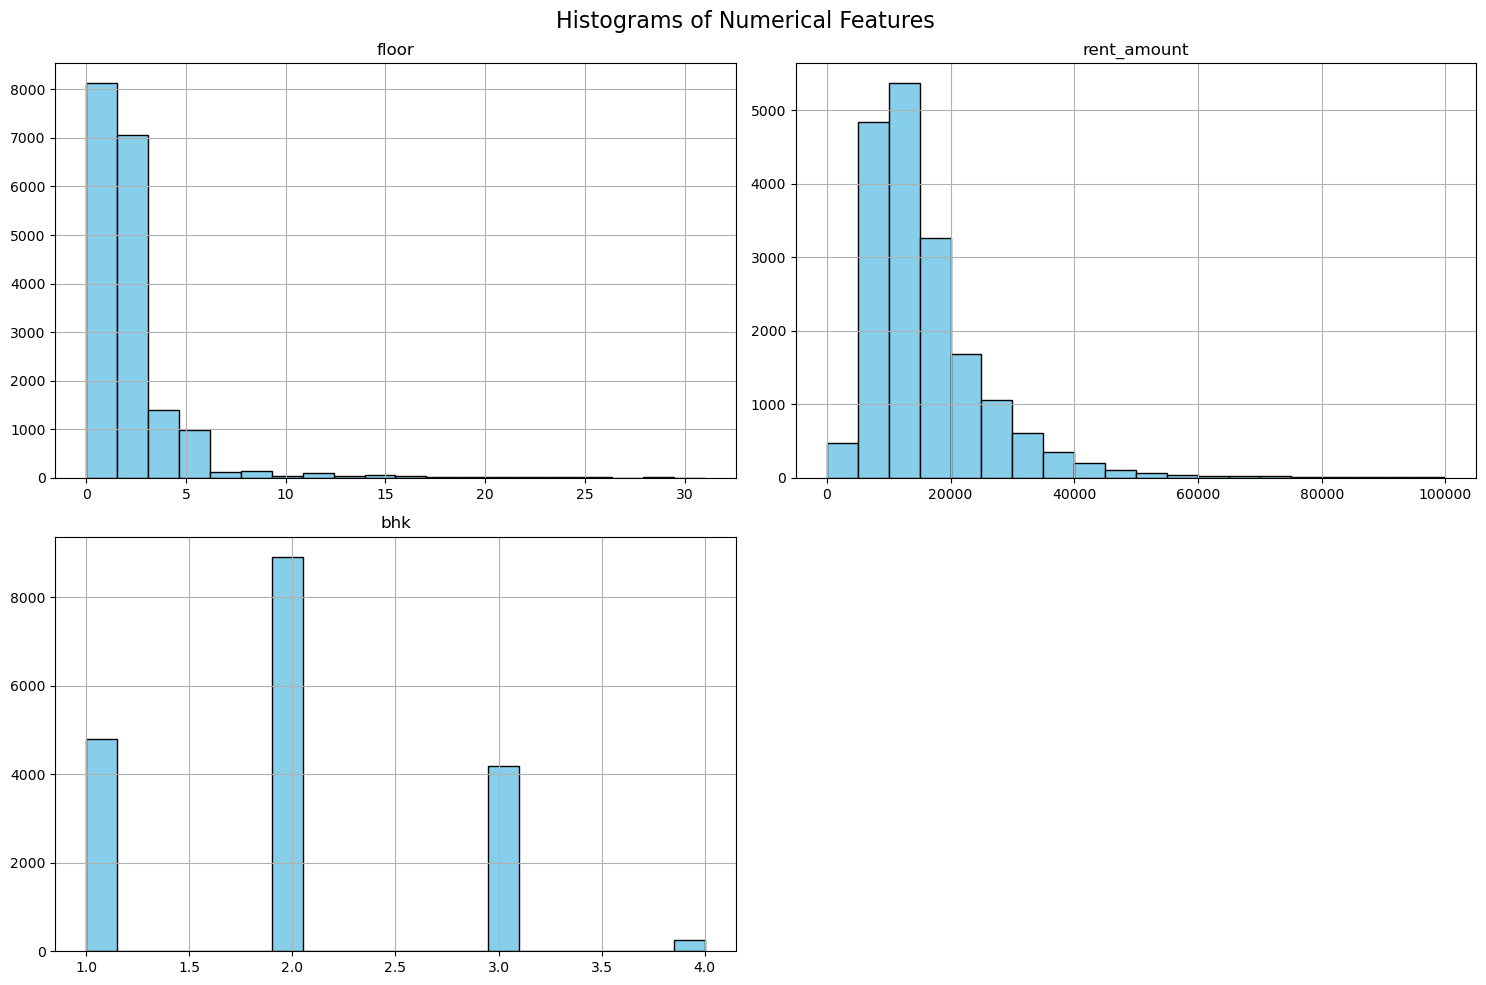

In [50]:
# Histogram for all Numerical Columns
data3.hist(bins = 20, figsize = (15,10), color = "skyblue", edgecolor = 'black')
plt.suptitle("Histograms of Numerical Features", fontsize = 16)
plt.tight_layout()
plt.show()

In [52]:
data3.dtypes

locality       object
floor           int64
lift             bool
parkingDesc    object
rent_amount     int64
bhk             int64
dtype: object

In [54]:
data4 = data3.copy()

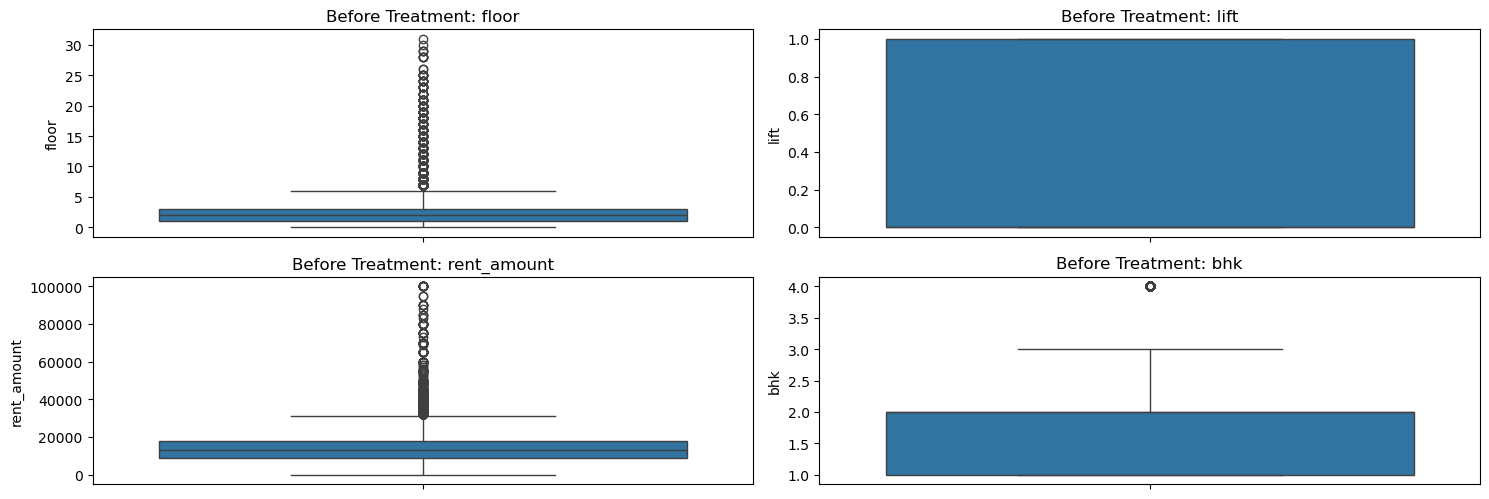

In [56]:
# Select numerical columns
numerical_cols = data4.select_dtypes(include=['int64','bool','int32']).columns

# Function to detect and treat outliers using IQR
def treat_outliers_iqr(data4, column):
    Q1 = data4[column].quantile(0.25)
    Q3 = data4[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers
    data4[column] = np.where(data4[column] < lower_bound, lower_bound, data4[column])
    data4[column] = np.where(data4[column] > upper_bound, upper_bound, data4[column])
    return df

# Visualize outliers before treatment
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(y=data4[col])
    plt.title(f'Before Treatment: {col}')
plt.tight_layout()
plt.show()


In [58]:
data4.floor.unique()

array([ 3,  2,  0,  5, 20,  1,  4, 13,  6, 14, 11,  9,  8, 15,  7, 10, 23,
       18, 31, 17, 16, 21, 12, 22, 25, 19, 24, 30, 26, 28, 29],
      dtype=int64)

In [60]:
data4.floor.value_counts().head(10)

floor
1    4488
2    4408
0    3642
3    2648
4    1398
5     824
6     154
7     113
8      80
9      66
Name: count, dtype: int64

In [62]:
data4.shape

(18154, 6)

In [64]:
data5 = data4[data4.floor<10]

In [66]:
data5.shape

(17821, 6)

<Axes: ylabel='floor'>

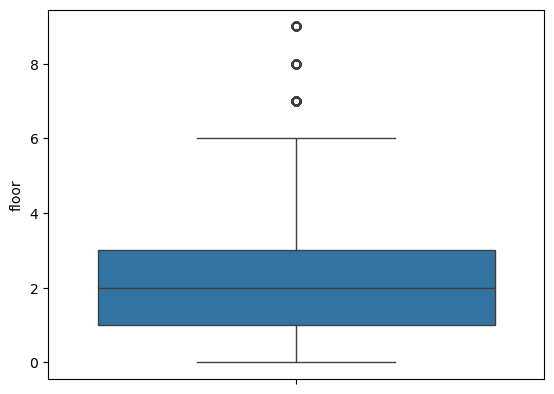

In [68]:
  sns.boxplot(y=data5['floor'])

In [70]:
data5.value_counts()

locality    floor  lift   parkingDesc  rent_amount  bhk
Kondapur    2      False  1            10000        1      25
Kukatpally  0      False  1            7000         1      21
Kondapur    1      False  1            10000        1      20
Kukatpally  1      False  1            13000        2      17
            2      False  1            12000        2      16
                                                           ..
Jeedimetla  5      False  3            17000        2       1
                                       20000        3       1
                   True   3            13500        2       1
                                       25000        2       1
zzathnagar  4      True   1            9000         1       1
Name: count, Length: 13928, dtype: int64

In [72]:
data5.rent_amount.value_counts().head(20)

rent_amount
10000    1314
12000    1207
15000    1183
8000      798
20000     743
9000      736
13000     727
14000     700
18000     668
16000     635
11000     601
7000      568
25000     540
6000      473
8500      463
7500      427
6500      395
30000     381
22000     363
17000     343
Name: count, dtype: int64

In [74]:
data5.describe()

,floor,rent_amount,bhk
count,17821.000000,17821.000000,17821.000000
mean,1.902755,14836.357780,1.981819
std,1.605729,9240.732221,0.738933
min,0.000000,0.000000,1.000000
25%,1.000000,9000.000000,1.000000
50%,2.000000,12500.000000,2.000000
75%,3.000000,18000.000000,2.000000
max,9.000000,100000.000000,4.000000


In [76]:
data5[data5.rent_amount > 30000]

,locality,floor,lift,parkingDesc,rent_amount,bhk
4,HITEC City,2,True,3,32500,2
5,Kondapur,5,True,3,33000,3
15,Gachibowli,3,True,1,50000,4
24,Banjara Hills,1,False,2,40000,3
30,Banjara Hills,1,True,3,50000,3
...,...,...,...,...,...,...
19004,Hitec City,0,True,3,35000,3
19005,Hitec City,0,True,3,35000,3
19008,Kondapur,6,True,3,36000,3
19010,Kukatpally,8,True,3,40000,3


In [78]:
data6 = data5[data5.rent_amount < 30000]

In [80]:
data6.shape

(16560, 6)

In [82]:
data6.bhk.value_counts()

bhk
2    8720
1    4776
3    2985
4      79
Name: count, dtype: int64

In [84]:
data6[data6.bhk>3]

,locality,floor,lift,parkingDesc,rent_amount,bhk
195,Kismatpur,0,False,3,20000,4
334,Sainikpuri,0,False,3,22500,4
411,Bhoiguda,1,False,3,16000,4
770,Yapral,0,False,3,20000,4
997,Toli Chowki,2,False,1,14000,4
...,...,...,...,...,...,...
17216,West Marredpally,2,False,3,25000,4
17461,Baachupally,0,True,3,20000,4
18236,Dollar Hills Gate No. 4,1,False,3,20000,4
18259,"Aziz Bagh Colony, Toli Chowki",1,False,3,16000,4


In [86]:
data7 = data6[data6.bhk<4]

In [88]:
data7.shape

(16481, 6)

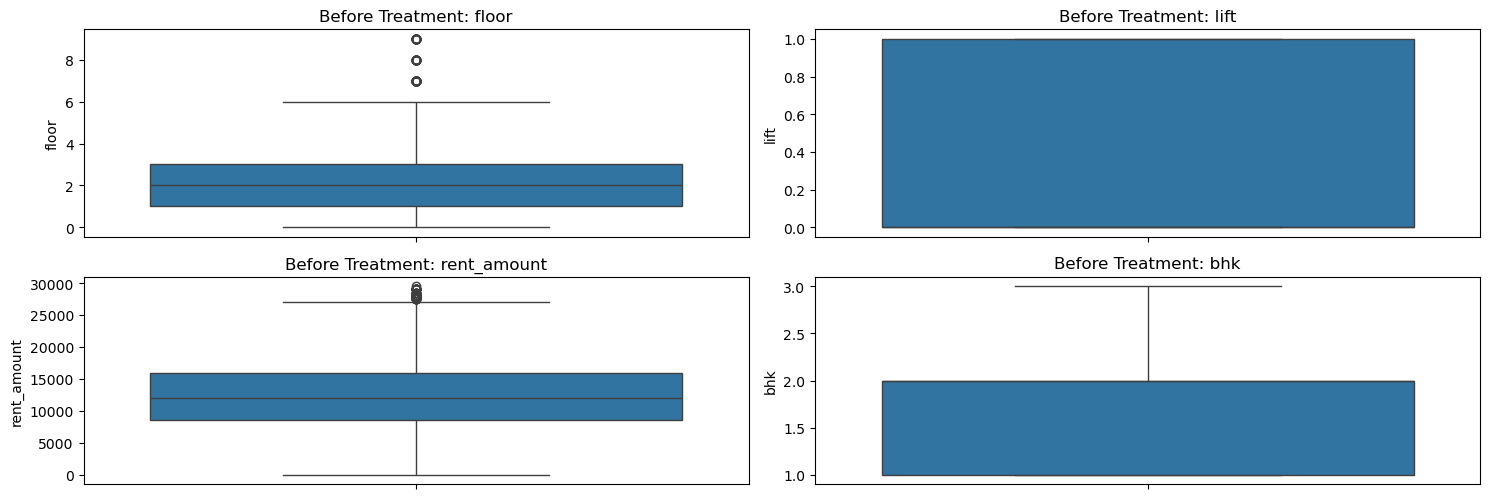

In [90]:
numerical_cols = data7.select_dtypes(include=['int64','bool','int32']).columns

# Function to detect and treat outliers using IQR


# Visualize outliers before treatment
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(y=data7[col])
    plt.title(f'Before Treatment: {col}')
plt.tight_layout()
plt.show()

In [92]:
data7.head()

,locality,floor,lift,parkingDesc,rent_amount,bhk
0,Gachibowli,3,True,3,28000,3
1,Chandrayangutta,2,False,1,15000,3
2,Manikonda,0,True,3,16000,3
3,LB Nagar,2,False,3,9000,2
7,Vignanpuri Colony,2,False,3,9500,2


In [94]:
data7.shape

(16481, 6)

In [125]:
df = pd.get_dummies(data7, columns=["locality"], prefix="locality")
model_columns = df.columns.tolist()
joblib.dump(model_columns, "dummy_columns.pkl")



['dummy_columns.pkl']

In [98]:
#import joblib
#dummies_df = pd.get_dummies(data7.locality)
#joblib.dump(dummies_df.columns.tolist(), "dummy_columns.pkl")

['dummy_columns.pkl']

In [127]:
dummies_df.shape

(16481, 2464)

In [129]:
data8 = pd.concat([data7,dummies_df],axis = 'columns')
data8.head(2)

,locality,floor,lift,parkingDesc,rent_amount,bhk,Chanda Nagar,Kukatpally,Nacharam,A. S. Rao Nagar,...,vijayavada road,"vivekanandanagar colony, gowlidoddy,vattinagulapally",west hanuman nagar Boduppal,whisper valley,yellammabanda.com,"yousuf manzil, Kachiguda Kamela",yousufguda,yousufguda,zamistanpur,zzathnagar
0,Gachibowli,3,True,3,28000,3,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,Chandrayangutta,2,False,1,15000,3,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [131]:
data8.shape

(16481, 2470)

In [133]:
data9 = data8.drop('locality', axis = 1)
data9.head(2)

,floor,lift,parkingDesc,rent_amount,bhk,Chanda Nagar,Kukatpally,Nacharam,A. S. Rao Nagar,Adikmet,...,vijayavada road,"vivekanandanagar colony, gowlidoddy,vattinagulapally",west hanuman nagar Boduppal,whisper valley,yellammabanda.com,"yousuf manzil, Kachiguda Kamela",yousufguda,yousufguda,zamistanpur,zzathnagar
0,3,True,3,28000,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,False,1,15000,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [135]:
data9.shape

(16481, 2469)

In [137]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data9)

data10 = pd.DataFrame(scaled_data, columns=data9.columns)
print(data10)

          floor      lift  parkingDesc  rent_amount       bhk    Chanda Nagar  \
0      0.771133  1.523189     0.977425     2.631565  1.636253        -0.00779   
1      0.109410 -0.656517    -1.082147     0.353694  1.636253        -0.00779   
2     -1.214035  1.523189     0.977425     0.528915  1.636253        -0.00779   
3      0.109410 -0.656517     0.977425    -0.697630  0.160384        -0.00779   
4      0.109410 -0.656517     0.977425    -0.610020  0.160384        -0.00779   
...         ...       ...          ...          ...       ...             ...   
16476 -1.214035  1.523189     0.977425    -0.785241 -1.315486        -0.00779   
16477  0.109410 -0.656517     0.977425    -0.785241  0.160384        -0.00779   
16478  0.771133 -0.656517     0.977425     0.353694  0.160384        -0.00779   
16479  0.771133 -0.656517    -1.082147    -1.048072 -1.315486        -0.00779   
16480 -0.552312 -0.656517    -1.082147    -1.310903 -1.315486        -0.00779   

         Kukatpally    Nach

In [139]:
X = data10.drop("rent_amount", axis = 1)
X.head()

,floor,lift,parkingDesc,bhk,Chanda Nagar,Kukatpally,Nacharam,A. S. Rao Nagar,Adikmet,Alluri Seetaramaraju Nagar,...,vijayavada road,"vivekanandanagar colony, gowlidoddy,vattinagulapally",west hanuman nagar Boduppal,whisper valley,yellammabanda.com,"yousuf manzil, Kachiguda Kamela",yousufguda,yousufguda,zamistanpur,zzathnagar
0,0.771133,1.523189,0.977425,1.636253,-0.00779,-0.00779,-0.00779,-0.011017,-0.00779,-0.011017,...,-0.00779,-0.00779,-0.00779,-0.00779,-0.011017,-0.00779,-0.00779,-0.00779,-0.00779,-0.00779
1,0.109410,-0.656517,-1.082147,1.636253,-0.00779,-0.00779,-0.00779,-0.011017,-0.00779,-0.011017,...,-0.00779,-0.00779,-0.00779,-0.00779,-0.011017,-0.00779,-0.00779,-0.00779,-0.00779,-0.00779
2,-1.214035,1.523189,0.977425,1.636253,-0.00779,-0.00779,-0.00779,-0.011017,-0.00779,-0.011017,...,-0.00779,-0.00779,-0.00779,-0.00779,-0.011017,-0.00779,-0.00779,-0.00779,-0.00779,-0.00779
3,0.109410,-0.656517,0.977425,0.160384,-0.00779,-0.00779,-0.00779,-0.011017,-0.00779,-0.011017,...,-0.00779,-0.00779,-0.00779,-0.00779,-0.011017,-0.00779,-0.00779,-0.00779,-0.00779,-0.00779
4,0.109410,-0.656517,0.977425,0.160384,-0.00779,-0.00779,-0.00779,-0.011017,-0.00779,-0.011017,...,-0.00779,-0.00779,-0.00779,-0.00779,-0.011017,-0.00779,-0.00779,-0.00779,-0.00779,-0.00779


In [140]:
y = data10.rent_amount
y.head()

0    2.631565
1    0.353694
2    0.528915
3   -0.697630
4   -0.610020
Name: rent_amount, dtype: float64

In [142]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state = 10)

In [146]:
from sklearn.linear_model import  LinearRegression
lr_clf = LinearRegression()
lr_clf.fit(X_train,y_train)
lr_clf.score(X_test,y_test)

0.6953789956213868

In [147]:
import joblib

lr_clf.fit(X_train, y_train)
joblib.dump(lr_clf, "best_LinearRegression_model.pkl")


['best_LinearRegression_model.pkl']

In [ ]:
from sklearn.model_selection import  ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

cross_val_score(LinearRegression(), X,y, cv=cv)

In [ ]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, ShuffleSplit
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def find_best_model_using_gridsearchcv(X, y):
    algos = {
        'linear_regression': {
            'model': Pipeline([
                ('scaler', StandardScaler()),
                ('lr', LinearRegression())
            ]),
            'params': {
                'lr__fit_intercept': [True, False],
                'lr__positive': [True, False]
            }
        },

        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [1, 2],
                'selection': ['random', 'cyclic']
            }
        },

        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion': ['friedman_mse'],
                'splitter': ['best', 'random']
            }
        }
    }

    scores = []
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

    for algo_name, config in algos.items():
        gs = GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False, n_jobs=-1, verbose=1)
        gs.fit(X, y)
        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })

    return pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])

# Run the function
df_results = find_best_model_using_gridsearchcv(X, y)
print(df_results)


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor

def find_best_model_using_gridsearchcv(X,y):
    algos = {
        'linear_regression' : {
            'model' : LinearRegression(),
            'params' : {
               'fit_intercept': [True, False],
            }

        },

        'lasso': { 
            'model' : Lasso(),
            'params' : {
                'alpha' : [1,2],
                'selection' : ['random', 'cyclic']

            }
        },

        'decision_tree' : {
            'model' : DecisionTreeRegressor(),
            'params' : {
                'criterion' : ['mse', 'friedman_mse'],
                'splitter' : ['best', 'random']

            }

        }

    }

    scores = []
    cv = ShuffleSplit(n_splits=2, test_size=0.2, random_state=0)
    
    for algos_name, config in algos.items():
        gs = GridSearchCV(config['model'],config['params'], cv=cv, return_train_score=False)
        gs.fit(X, y)
        scores.append({
            'model' : algos_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })

    return pd.DataFrame(scores,columns=['model','best_score', 'best_params'])
    
result = find_best_model_using_gridsearchcv(X,y)
print(result)